In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/paysim.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.drop(columns = ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1, inplace = True)

In [5]:
print(df.shape)
print(df.isnull().sum())

(6362620, 8)
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


In [6]:
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

In [7]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
X_train_small = X_train.sample(100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [10]:
small_grid = {
    "n_estimators": [100, 150],
    "max_depth": [7, 10],
    "min_samples_split": [2, 5]
}

In [11]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    param_distributions=small_grid,
    n_iter=4,
    scoring="recall",
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_small, y_train_small)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


RandomizedSearchCV(cv=2,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': [7, 10],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 150]},
                   random_state=42, scoring='recall', verbose=2)

In [12]:
print(random_search.best_params_)

{'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 7}


In [14]:
X_train_final = X_train.sample(500000, random_state=42)
y_train_final = y_train.loc[X_train_final.index]

In [15]:
best_rf = RandomForestClassifier(
    n_estimators=random_search.best_params_["n_estimators"],
    max_depth=random_search.best_params_["max_depth"],
    min_samples_split=random_search.best_params_["min_samples_split"],
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

best_rf.fit(X_train_final, y_train_final)

RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=150,
                       n_jobs=-1, random_state=42)

In [16]:
pred = best_rf.predict(X_test)
proba = best_rf.predict_proba(X_test)[:,1]

In [17]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, proba))

Accuracy : 0.9827853934385521
Precision: 0.06719637746166005
Recall   : 0.9573950091296409
F1 Score : 0.12557879610410347
ROC AUC  : 0.9971644873054484


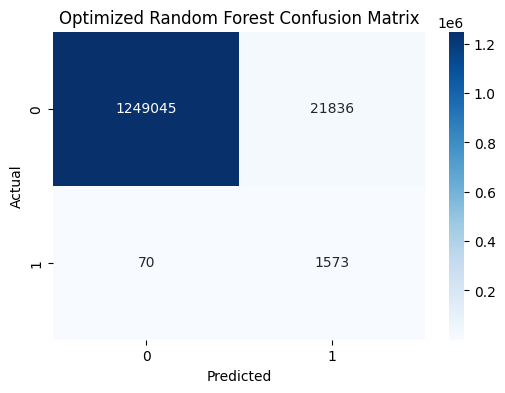

In [26]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.96      0.13      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524



In [27]:
joblib.dump(best_rf, "/content/fraud_model.pkl")

['/content/fraud_model.pkl']

In [28]:
print("Optimized Random Forest model saved successfully.")

Optimized Random Forest model saved successfully.
